In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt


In [31]:
from pandas import DataFrame

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))
all_visits = {}

for file in csv_files:
    df = pd.read_csv(file, sep=";")

    filename = file.stem
    visit = filename.split("_")[1]

    df["visit"] = visit

    all_visits[visit] = df

C:\Users\karlw\AppData\Local\Temp\ipykernel_13268\252853293.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["visit"] = visit
C:\Users\karlw\AppData\Local\Temp\ipykernel_13268\252853293.py:8: DtypeWarning: Columns (0: ichd3_4_K1, 1: comment_4_K1, 2: adverse2_a5_K1, 3: adverse3_a5_K1, 4: adverse1_a6_K1, 5: adverse2_a6_K1, 6: adverse3_a6_K1, 7: acute_name_a7_K1, 8: dosage_unit_a7_K1, 9: dosage_admin_a7_K1, 10: adverse1_a7_K1, 11: adverse2_a7_K1, 12: adverse3_a7_K1, 13: acute_name_a8_K1, 14: dosage_unit_a8_K1, 15: dosage_admin_a8_K1, 16: adverse1_a8_K1, 17: adverse2_a8_K1, 18: adverse3_a8_K1, 19: acute_name_a9_K1, 20: dosage_unit_a9_K1, 21: dosage_admin_a9_K1, 22: adverse1_a9_K1, 23: acute_name_a10_K1, 24: dosage_unit_a10_K1, 25: dosage_admin_a10_K1, 26

In [32]:
top_meds_per_visit = {}

for visit, df in all_visits.items():
    MED_COLUMN = f"acute_name_a1_K{visit[1:]}"
    if MED_COLUMN not in df.columns:
        print(f"{visit}: Spalte {MED_COLUMN} nicht gefunden")
        continue

    meds = (
        df[MED_COLUMN]
        .dropna()
        .astype(str)
        .str.strip()
    )

    meds = meds[(meds != "") & (meds != "0")]

    top_meds = meds.value_counts().head(20)

    top_meds_per_visit[visit] = top_meds

Vlast: Spalte acute_name_a1_Klast nicht gefunden


In [35]:
dfs = []
PATIENT_ID_COLUMN = "id_patient"

for visit, df in all_visits.items():

    med_col = f"acute_name_a1_K{visit[1:]}"

    if med_col not in df.columns:
        print(f"{visit}: Spalte {med_col} fehlt")
        continue

    temp = df[[PATIENT_ID_COLUMN, med_col]].copy()
    temp["visit"] = visit

    temp = temp.rename(columns={med_col: "medication"})

    dfs.append(temp)

combined_df = pd.concat(dfs, ignore_index=True)

print("\nGesamte Zeilen:", len(combined_df))

Vlast: Spalte acute_name_a1_Klast fehlt

Gesamte Zeilen: 17866


In [40]:
PATIENT_ID_COLUMN = "id_patient"


relevant = combined_df.dropna(subset=[PATIENT_ID_COLUMN])

relevant["medication"] = (
    relevant["medication"]
    .fillna("")
    .astype(str)
    .str.strip()
)

relevant = relevant[(relevant["medication"] != "") & (relevant["medication"] != "0")]
visit_order = sorted(
    [v for v in all_visits.keys() if v[1:].isdigit()],
    key=lambda v: int(v[1:])
)

print("\nVisit Reihenfolge:")
print(visit_order)


Visit Reihenfolge:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23']


In [41]:
changes = []

for patient_id, patient_df in relevant.groupby(PATIENT_ID_COLUMN):

    patient_visits = {}

    for visit in visit_order:

        visit_df = patient_df[patient_df["visit"] == visit]

        meds = set(
            visit_df["medication"]
            .dropna()
            .astype(str)
            .str.strip()
        )

        meds = {m for m in meds if m != "" and m != "0"}

        patient_visits[visit] = meds

    for i in range(len(visit_order) - 1):

        current_visit = visit_order[i]
        next_visit = visit_order[i + 1]

        current_meds = patient_visits.get(current_visit, set())
        next_meds = patient_visits.get(next_visit, set())

        added = next_meds - current_meds
        removed = current_meds - next_meds

        if added or removed:
            changes.append({
                "id_patient": patient_id,
                "from_visit": current_visit,
                "to_visit": next_visit,
                "added_meds": list(added),
                "removed_meds": list(removed),
                "n_added": len(added),
                "n_removed": len(removed)
            })

changes_df = pd.DataFrame(changes)

print("\n" + "=" * 50)
print("MEDIKAMENTEN-ÄNDERUNGEN")
print("=" * 50)

display(changes_df.head(20))


MEDIKAMENTEN-ÄNDERUNGEN


,id_patient,from_visit,to_visit,added_meds,removed_meds,n_added,n_removed
0,10007520,V1,V2,[],[Rizatriptan],0,1
1,10070992,V1,V2,[Metamizol],[Ibuprofen],1,1
2,10070992,V3,V4,[],[Metamizol],0,1
3,10072456,V1,V2,[],[Ibuprofen],0,1
4,10076150,V1,V2,[],[Ibuprofen],0,1
5,10076484,V2,V3,[Metamizol],[Ibuprofen],1,1
6,10076484,V3,V4,[Ibuprofen],[Metamizol],1,1
7,10076484,V5,V6,[],[Ibuprofen],0,1
8,10098623,V1,V2,[],[Rizatriptan],0,1
9,10098623,V2,V3,[Rizatriptan],[],1,0


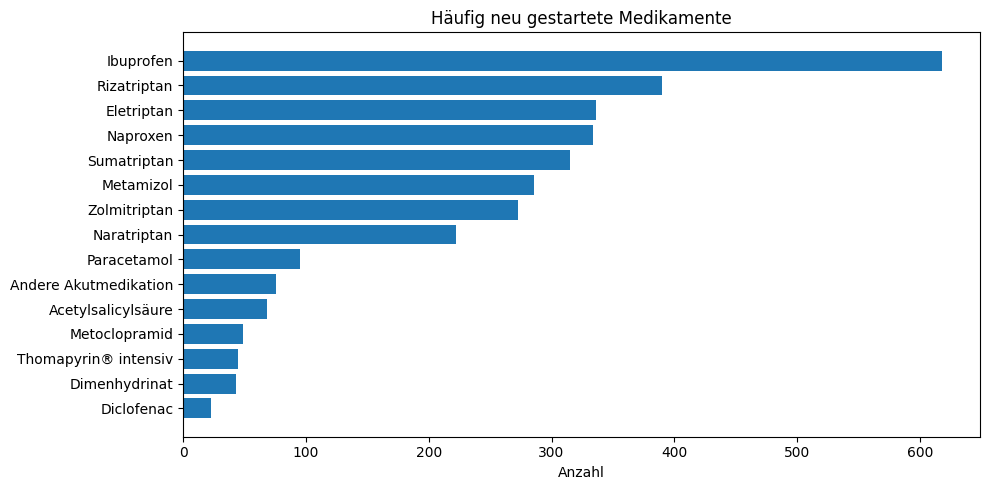

In [42]:
from collections import Counter

added_counter = Counter()

for meds in changes_df["added_meds"]:
    added_counter.update(meds)

top_added = pd.DataFrame(added_counter.most_common(15), columns=["medication", "count"])

plt.figure(figsize=(10,5))
plt.barh(top_added["medication"][::-1], top_added["count"][::-1])
plt.title("Häufig neu gestartete Medikamente")
plt.xlabel("Anzahl")
plt.tight_layout()
plt.show()

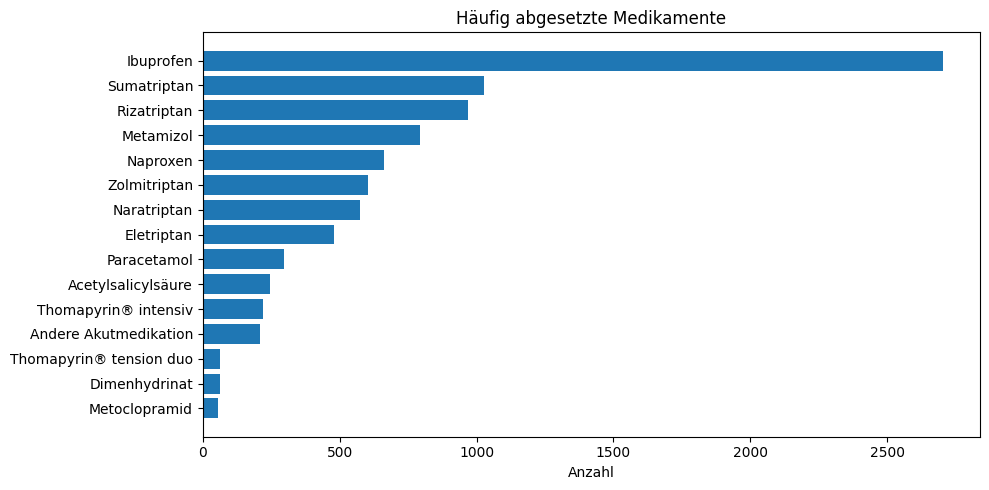

In [43]:
removed_counter = Counter()

for meds in changes_df["removed_meds"]:
    removed_counter.update(meds)

top_removed = pd.DataFrame(removed_counter.most_common(15), columns=["medication", "count"])

plt.figure(figsize=(10,5))
plt.barh(top_removed["medication"][::-1], top_removed["count"][::-1])
plt.title("Häufig abgesetzte Medikamente")
plt.xlabel("Anzahl")
plt.tight_layout()
plt.show()